In [27]:
import os, scipy.io
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.io import loadmat
import matplotlib.ticker as ticker
import copy

In [28]:
data_cf = h5py.File('forgetting_three_class-mnist&fashion.mat','r')

#-------------------------------------------------------------------------------------
with data_cf as file:
    para_1_history = [np.array(file[ref]) for ref in file['para_1_history']]

    para_2_history = [np.array(file[ref]) for ref in file['para_2_history']]

data_cf = h5py.File('forgetting_three_class-mnist&fashion.mat','r')

In [29]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['figure.figsize'] = 20, 15
plt.rcParams.update({'font.size': 34})

colors = [ [c/255 for c in [42, 176, 128] ], 
         [c/255 for c in [58, 110, 178] ],
        [c/255 for c in [202, 62, 114] ] ] ;

order_size = 45 ;
lw_ = 3 ;
ms = 10 ;
length = data_cf["length_"][:] ;

## Results for catastrophic forgetting in quantum learning¶

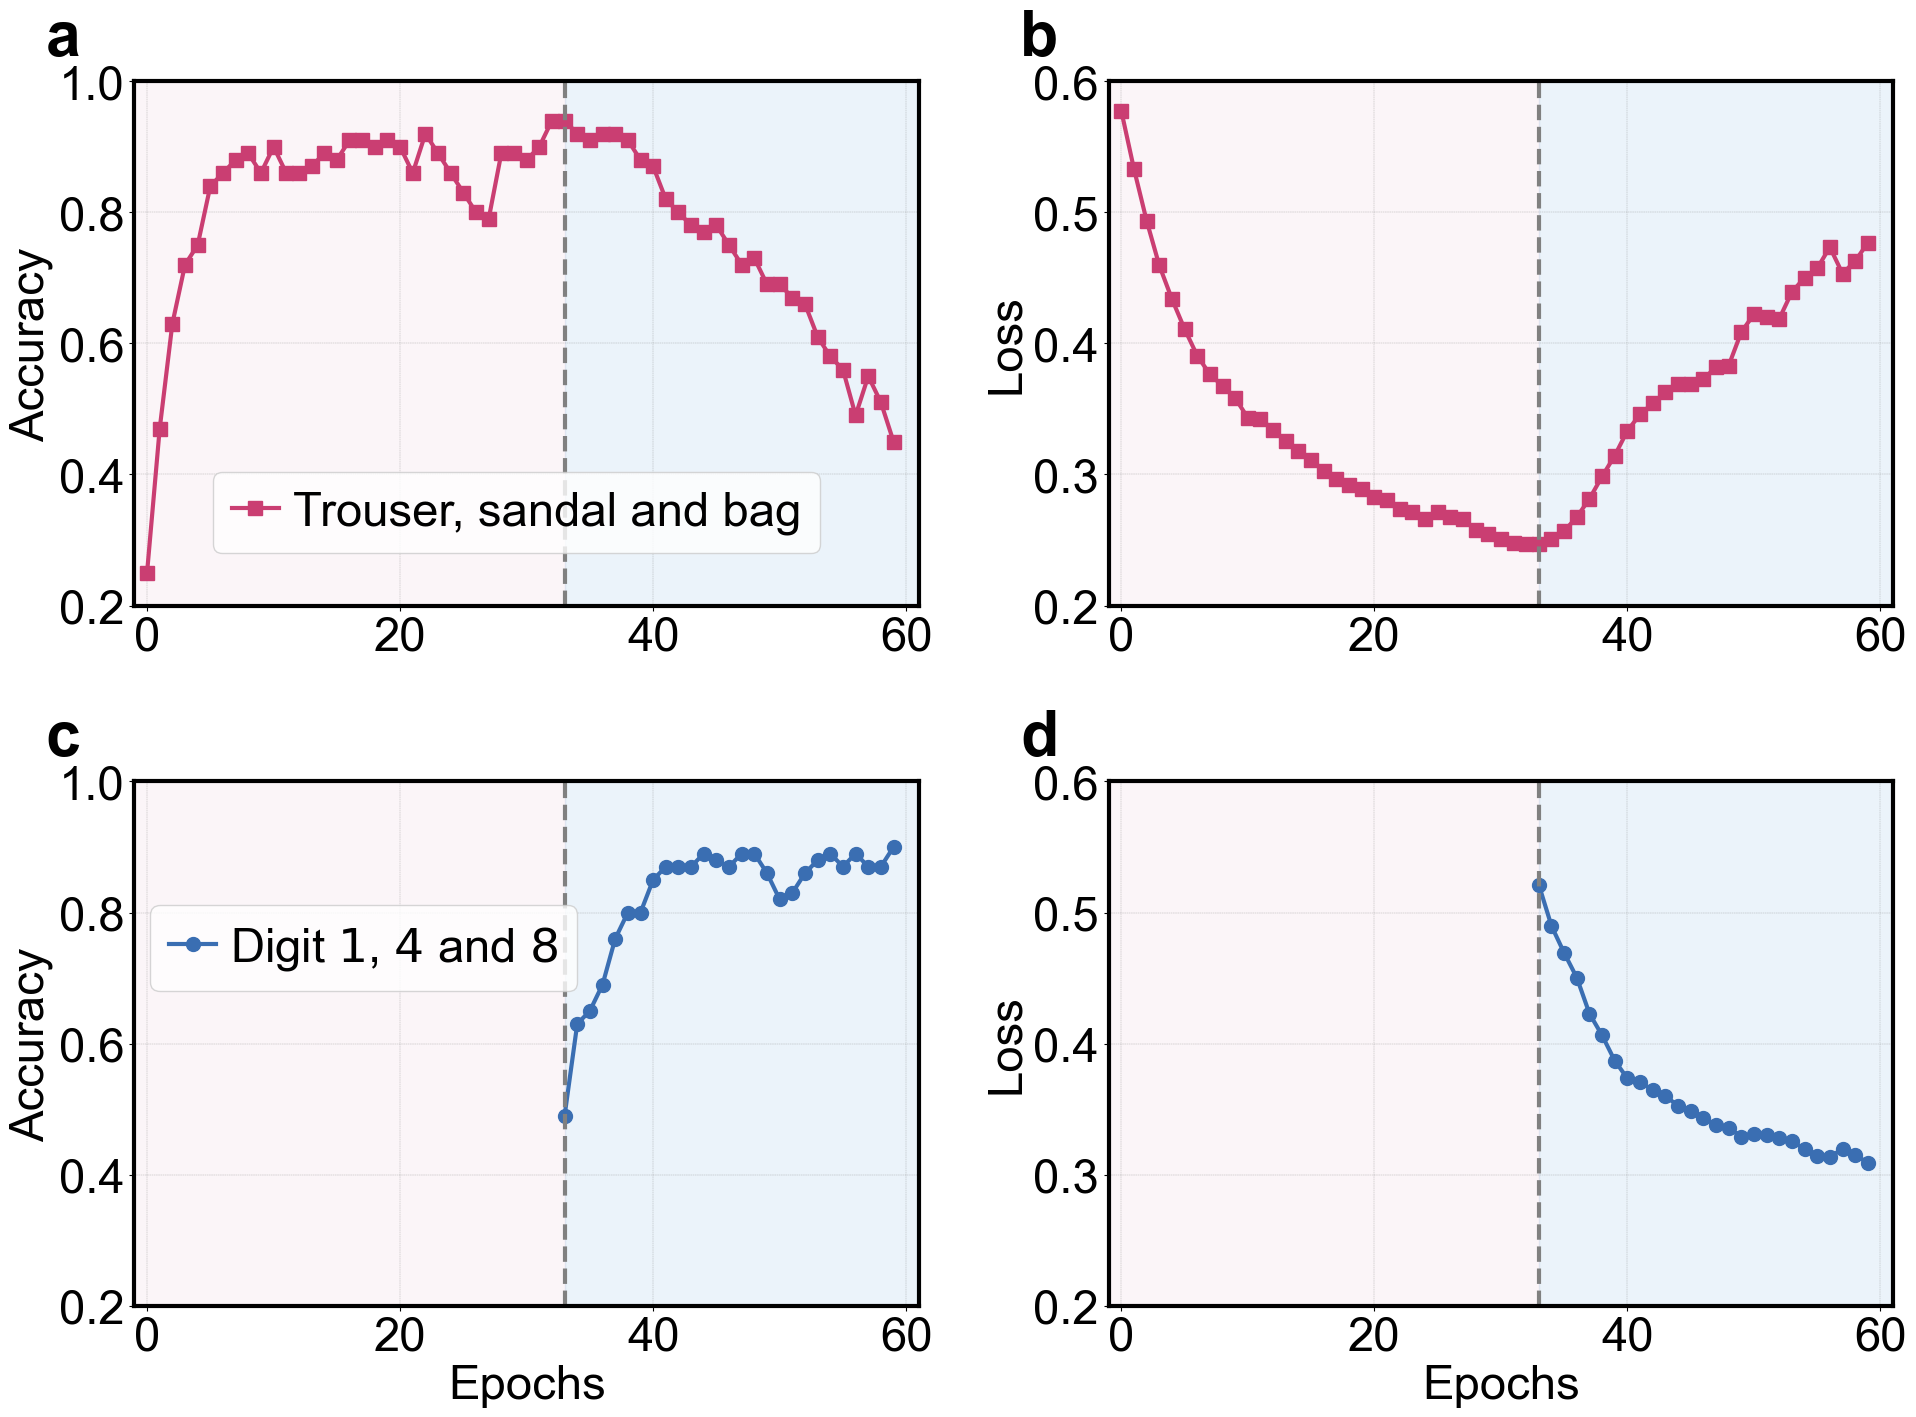

In [30]:
fig, ((ax11, ax12),(ax21, ax22)) = plt.subplots(2, 2)
w = 3 ;
for ax in [ax11, ax12, ax21, ax22]:
    ax.spines['bottom'].set_linewidth(w)  
    ax.spines['top'].set_linewidth(w)     
    ax.spines['left'].set_linewidth(w)    
    ax.spines['right'].set_linewidth(w)   
    
ax11.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax12.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax21.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax22.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)

#--------------------------------------------------------------------------------------------------
ax11.text(-8, 1.04, 'a', fontsize=order_size, fontweight='bold')

ax11.set_ylim([0.2, 1])
ax11.set_xlim([-1, sum(length)+1])
ax11.yaxis.set_major_locator(ticker.MultipleLocator(0.2))   

ax11.set_ylabel('Accuracy')
# ax11.set_xlabel('Epochs')

length = data_cf["length_"][:] ;
acc_task1 = data_cf["acc_task1"][:] ;  acc_task2 = data_cf["acc_task2"][:] ;
loss_task1 = data_cf["loss_task1"][:] ; loss_task2 = data_cf["loss_task2"][:] ;

ax11.plot(np.arange(sum(length)), acc_task1, color = colors[2], marker='s',  markersize = ms, 
          linewidth = lw_, markevery = 1, label='Trouser, sandal and bag')

ax11.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
ax11.legend(frameon=True, loc=(0.1,0.1), labelspacing=0.5, handlelength=1, handletextpad = 0.3)
#--------------------------------------------------------------------------------------------------


ax21.text(-8, 1.04, 'c', fontsize=order_size, fontweight='bold')

ax21.set_ylim([0.2,1])
ax21.set_xlim([-1, sum(length)+1])
ax21.yaxis.set_major_locator(ticker.MultipleLocator(0.2))   

ax21.set_ylabel('Accuracy')
ax21.set_xlabel('Epochs')

ax21.plot(np.arange(length[0], sum(length) ), acc_task2, color= colors[1], marker='o', 
          markevery=1, alpha=1, markersize = ms, label = 'Digit $1$, $4$ and $8$', linewidth = lw_) 
#
ax21.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
ax21.legend(frameon=True, loc=(0.02,0.6), labelspacing=0.5, handlelength=1, handletextpad = 0.3)
#--------------------------------------------------------------------------------------------------

ax12.text(-8, 0.62, 'b', fontsize=order_size, fontweight='bold')
ax12.set_ylabel('Loss')
ax12.set_xlim([-1, sum(length)+1])
ax12.set_ylim(0.2, 0.6); ax12.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax12.plot(np.arange(sum(length)), loss_task1, color = colors[2], marker='s', markersize = ms, linewidth = lw_, 
          markevery=1, alpha=1, label='')

#
ax12.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
# ax12.legend(frameon=False, loc=(0.02,0.01), labelspacing=0.5)
#--------------------------------------------------------------------------------------------------

ax22.text(-8, 0.62, 'd', fontsize=order_size, fontweight='bold')
ax22.set_ylabel('Loss')
ax22.set_xlabel('Epochs')
ax22.set_xlim([-1, sum(length)+1])
ax22.set_ylim(0.2, 0.6); ax22.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

ax22.plot(np.arange(length[0], sum(length) ), loss_task2, color= colors[1], marker='o', markersize = ms, linewidth = lw_, 
          markevery=1, alpha=1,  label = '') 
#
ax22.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
#----------------------------------------------------------------

ax11.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax11.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax21.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax21.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax12.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax12.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax22.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax22.axvspan(length[0], sum(length)+1,color = [c/255 for c in [157, 195, 230] ], alpha=0.2)


plt.tight_layout()
plt.show()
# plt.subplots_adjust(left = 0.1, bottom = 0.10, top = 0.93, right = 0.84, hspace = 0.2, wspace = 0.2) ;

In [31]:
fig.savefig('forgetting_three_class-mnist&fashion.pdf', format='pdf', bbox_inches='tight', facecolor='None')

## Results for quantum continual learning with EWC

In [32]:
data_ewc = h5py.File('EWC_three_class-mnist&fashion.mat','r')

#-------------------------------------------------------------------------------------
with data_ewc as file:
    para_1_history = [np.array(file[ref]) for ref in file['para_1_history']]

    para_2_history = [np.array(file[ref]) for ref in file['para_2_history']]

data_ewc = h5py.File('EWC_three_class-mnist&fashion.mat','r')

In [33]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['figure.figsize'] = 20, 15
plt.rcParams.update({'font.size': 34})

colors = [ [c/255 for c in [42, 176, 128] ], 
         [c/255 for c in [58, 110, 178] ],
        [c/255 for c in [202, 62, 114] ] ] ;

order_size = 45 ;
lw_ = 3 ;
ms = 10 ;
length = data_ewc["length_"][:] ;

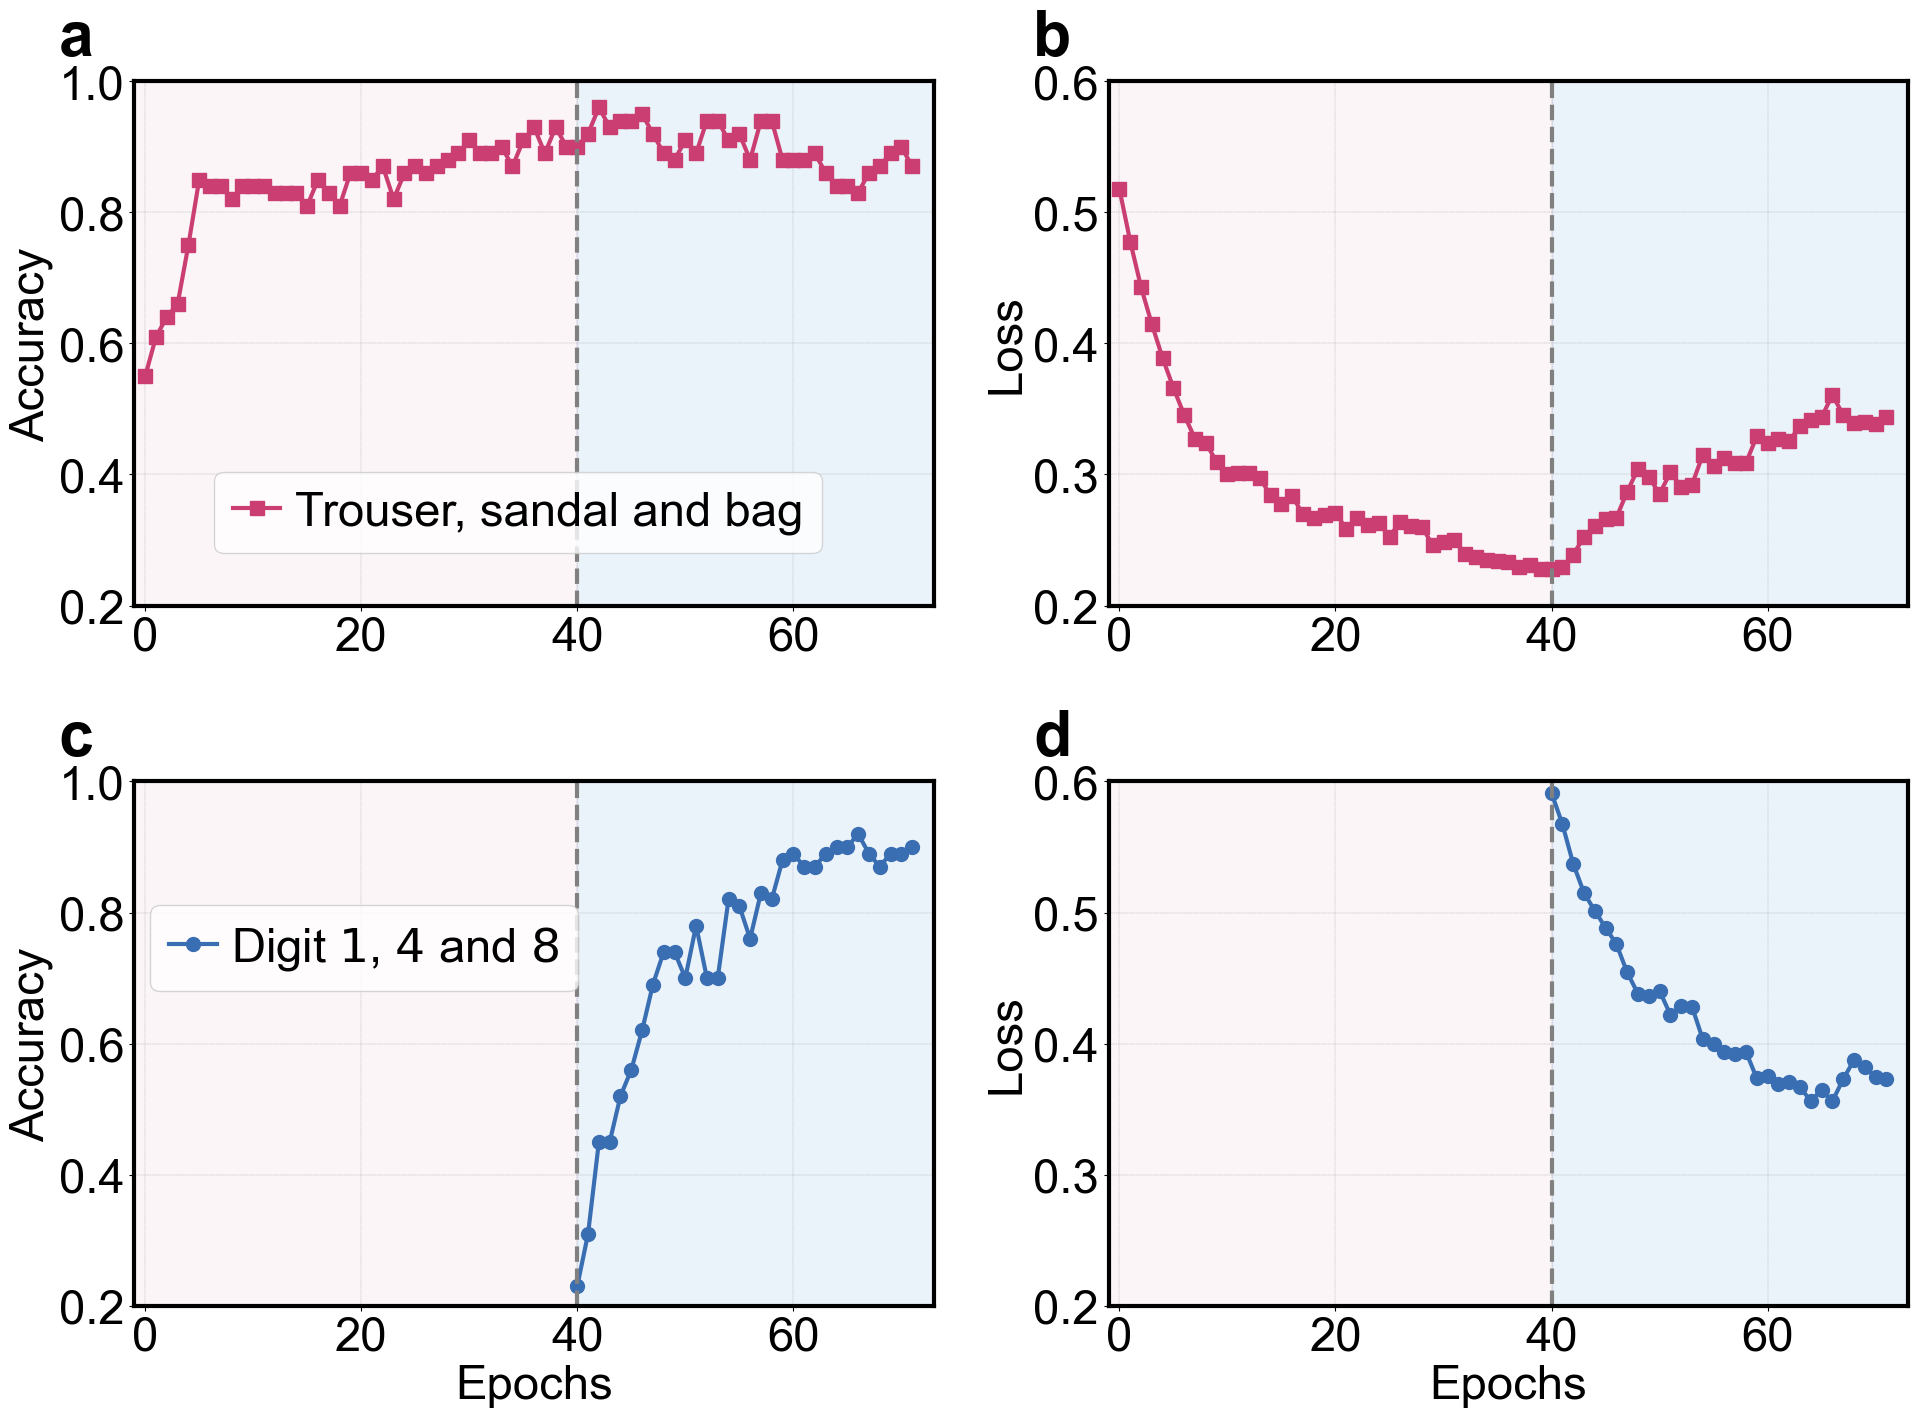

In [34]:
fig, ((ax11, ax12),(ax21, ax22)) = plt.subplots(2, 2)
w = 3 ;
for ax in [ax11, ax12, ax21, ax22]:
    ax.spines['bottom'].set_linewidth(w)  
    ax.spines['top'].set_linewidth(w)     
    ax.spines['left'].set_linewidth(w)    
    ax.spines['right'].set_linewidth(w)   
    
ax11.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax12.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax21.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)
ax22.grid(True, linestyle='--', linewidth=0.3, color='gray', alpha=0.7)

#--------------------------------------------------------------------------------------------------
ax11.text(-8, 1.04, 'a', fontsize=order_size, fontweight='bold')

ax11.set_ylim([0.2, 1])
ax11.set_xlim([-1, sum(length)+1])
ax11.yaxis.set_major_locator(ticker.MultipleLocator(0.2))   

ax11.set_ylabel('Accuracy')
# ax11.set_xlabel('Epochs')

acc_task1 = data_ewc["acc_task1"][:] ;  acc_task2 = data_ewc["acc_task2"][:] ;
loss_task1 = data_ewc["loss_task1"][:] ; loss_task2 = data_ewc["loss_task2"][:] ;

ax11.plot(np.arange(sum(length)), acc_task1, color = colors[2], marker='s',  markersize = ms, 
          linewidth = lw_, markevery = 1, label='Trouser, sandal and bag')

ax11.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
ax11.legend(frameon=True, loc=(0.1,0.1), labelspacing=0.5, handlelength=1, handletextpad = 0.3)
#--------------------------------------------------------------------------------------------------


ax21.text(-8, 1.04, 'c', fontsize=order_size, fontweight='bold')

ax21.set_ylim([0.2,1])
ax21.set_xlim([-1, sum(length)+1])
ax21.yaxis.set_major_locator(ticker.MultipleLocator(0.2))   

ax21.set_ylabel('Accuracy')
ax21.set_xlabel('Epochs')

ax21.plot(np.arange(length[0], sum(length) ), acc_task2, color= colors[1], marker='o', 
          markevery=1, alpha=1, markersize = ms, label = 'Digit $1$, $4$ and $8$', linewidth = lw_) 
#
ax21.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
ax21.legend(frameon=True, loc=(0.02,0.6), labelspacing=0.5, handlelength=1, handletextpad = 0.3)
#--------------------------------------------------------------------------------------------------

ax12.text(-8, 0.62, 'b', fontsize=order_size, fontweight='bold')
ax12.set_ylabel('Loss')
ax12.set_xlim([-1, sum(length)+1])
ax12.set_ylim(0.2, 0.6); ax12.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax12.plot(np.arange(sum(length)), loss_task1, color = colors[2], marker='s', markersize = ms, linewidth = lw_, 
          markevery=1, alpha=1, label='')

#
ax12.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
# ax12.legend(frameon=False, loc=(0.02,0.01), labelspacing=0.5)
#--------------------------------------------------------------------------------------------------

ax22.text(-8, 0.62, 'd', fontsize=order_size, fontweight='bold')
ax22.set_ylabel('Loss')
ax22.set_xlabel('Epochs')
ax22.set_xlim([-1, sum(length)+1])
ax22.set_ylim(0.2, 0.6); ax22.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

ax22.plot(np.arange(length[0], sum(length) ), loss_task2, color= colors[1], marker='o', markersize = ms, linewidth = lw_, 
          markevery=1, alpha=1,  label = '') 
#
ax22.axvline(x = length[0], color='grey', linestyle='--', linewidth = lw_)
#----------------------------------------------------------------

ax11.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax11.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax21.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax21.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax12.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax12.axvspan(length[0], sum(length)+1,color =  [c/255 for c in [157, 195, 230] ], alpha=0.2)
ax22.axvspan(-1,length[0],color = [c/255 for c in [244, 224, 232] ], alpha=0.3)
ax22.axvspan(length[0], sum(length)+1,color = [c/255 for c in [157, 195, 230] ], alpha=0.2)


plt.tight_layout()
plt.show()
# plt.subplots_adjust(left = 0.1, bottom = 0.10, top = 0.93, right = 0.84, hspace = 0.2, wspace = 0.2) ;

In [35]:
fig.savefig('EWC_three_class-mnist&fashion.pdf', format='pdf', bbox_inches='tight', facecolor='None')